# 01 · Exploratory Data Analysis

**Owner:** Riya (Model Lead) · **Course:** MDS471 Neural Networks & Deep Learning · **Project P5:** Telecom churn early-warning dashboard

**Goal.** Understand the data *before* modelling: how imbalanced is the target, which features separate churners from loyal customers, and which data-quality problems preprocessing must fix.

**Figures saved to `plots/`:** `churn_distribution.png` · `feature_distributions_by_churn.png` · `categorical_churn_rates.png` · `correlation_heatmap.png` · `churn_correlation_ranking.png`

> **Leakage note (viva).** EDA looks at all 7,043 rows but *fits nothing*: no mean, category list or threshold computed here is used by any model. Every fitted statistic is learned from the training split only (notebook 02).

In [1]:
# ── Environment setup: works on Google Colab (Drive) AND locally (VS Code / Jupyter) ──
import os, sys

try:
    from google.colab import drive  # only importable inside a Colab runtime
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/telco-churn-dashboard'
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    _cwd = os.path.abspath(os.getcwd())
    PROJECT_ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)                      # every relative path is now project-relative
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)        # lets us `import src...`
print('Project root:', PROJECT_ROOT, '| running on Colab:', IN_COLAB)

Project root: /Users/friday/Desktop/nndl/telco-churn-dashboard | running on Colab: False


In [2]:
# Colab already ships torch, numpy, pandas, scikit-learn, matplotlib and seaborn.
# Install the extras once per Colab session (skipped automatically when running locally).
if IN_COLAB:
    %pip install -q imbalanced-learn shap fastapi uvicorn jinja2 python-multipart joblib

## 1 · Download the dataset (run once)
Source: [IBM/telco-customer-churn-on-icp4d](https://github.com/IBM/telco-customer-churn-on-icp4d) — the same table as the Kaggle "Telco Customer Churn" dataset. `urllib` is used instead of `wget` so the cell also works on Windows/macOS.

In [3]:
from src import config

config.ensure_dirs()   # data/, models/, plots/, results/, logs/ ...
if not config.RAW_DATA_PATH.exists():
    import urllib.request
    urllib.request.urlretrieve(config.DATASET_URL, config.RAW_DATA_PATH)
    print('Downloaded ->', config.RAW_DATA_PATH)
else:
    print('Dataset already present:', config.RAW_DATA_PATH)

Dataset already present: /Users/friday/Desktop/nndl/telco-churn-dashboard/data/Telco-Customer-Churn.csv


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import plotting as P
from src.data_preprocessing import (CATEGORICAL_COLS, NUMERIC_COLS, TARGET_COL,
                                    clean_dataframe, load_raw_data)

P.apply_style()
PLOTS = config.PLOTS_DIR

raw_df = load_raw_data(config.RAW_DATA_PATH)   # also validates that all 21 columns exist
print('Shape:', raw_df.shape)
raw_df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2 · Data-quality check
`TotalCharges` should be numeric, yet pandas reads it as text. Let's find out why.

In [5]:
print('TotalCharges dtype:', raw_df['TotalCharges'].dtype, '<- expected a float!')
blank = raw_df['TotalCharges'].astype(str).str.strip() == ''
print(f'Blank TotalCharges strings: {blank.sum()}')
print('tenure of those rows      :', raw_df.loc[blank, 'tenure'].unique())
print('Rows with tenure == 0     :', int((raw_df['tenure'] == 0).sum()))
print('NaN cells in the file     :', int(raw_df.isna().sum().sum()))
print('Duplicate customerIDs     :', int(raw_df['customerID'].duplicated().sum()))
raw_df.loc[blank, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

TotalCharges dtype: str <- expected a float!
Blank TotalCharges strings: 11
tenure of those rows      : [0]
Rows with tenure == 0     : 11
NaN cells in the file     : 0
Duplicate customerIDs     : 0


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Finding.** 11 cells contain a single space `" "`, which forces the whole column to text. **All 11 rows have `tenure == 0`** and they are the *only* rows with `tenure == 0`: these are brand-new customers who have not received a first bill, so the amount charged so far is genuinely **₹0 → we fill with 0.0** (imputing the mean would invent ~2,280 of charges that never happened). `src/data_preprocessing.clean_dataframe` applies this rule; we use the cleaned frame for the plots below.

In [6]:
df, report = clean_dataframe(raw_df, require_target=True)
df['ChurnLabel'] = df[TARGET_COL].map({0: 'Retained', 1: 'Churned'})
print('Blank TotalCharges filled with 0.0:', report.total_charges_blank_filled)
print('TotalCharges dtype now:', df['TotalCharges'].dtype)
df[NUMERIC_COLS].describe().round(2)

Blank TotalCharges filled with 0.0: 11
TotalCharges dtype now: float64


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


## 3 · Churn distribution — the class imbalance

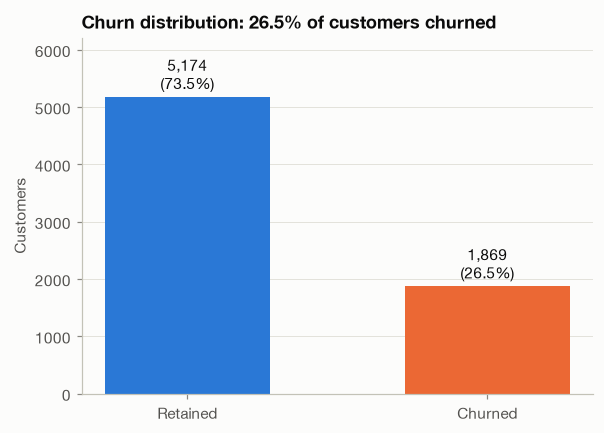

Imbalance ratio retained : churned = 2.77 : 1
Accuracy of a useless "nobody churns" model = 73.5%


In [7]:
counts = df['ChurnLabel'].value_counts().reindex(['Retained', 'Churned'])
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4.2))
bars = ax.bar(counts.index, counts.values, color=[P.RETAINED_COLOR, P.CHURN_COLOR], width=0.55)
for bar, n, p in zip(bars, counts.values, pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, n + 80, f'{n:,}\n({p:.1f}%)',
            ha='center', va='bottom', color=P.INK)
ax.set_ylim(0, counts.max() * 1.2)
ax.set_ylabel('Customers')
ax.grid(axis='x', visible=False)
ax.set_title(f'Churn distribution: {pct["Churned"]:.1f}% of customers churned')
P.save_figure(fig, PLOTS / 'churn_distribution.png')
plt.show()

print(f'Imbalance ratio retained : churned = {counts["Retained"] / counts["Churned"]:.2f} : 1')
print(f'Accuracy of a useless "nobody churns" model = {pct["Retained"]:.1f}%')

A classifier that always answers "no churn" is **73.5 % accurate but catches zero churners**. Accuracy is therefore meaningless here; we evaluate with churn-class precision/recall/F1 and **PR-AUC** (whose random baseline is the 26.5 % positive rate), and test explicit imbalance remedies in notebook 05.

## 4 · Numeric features by churn class

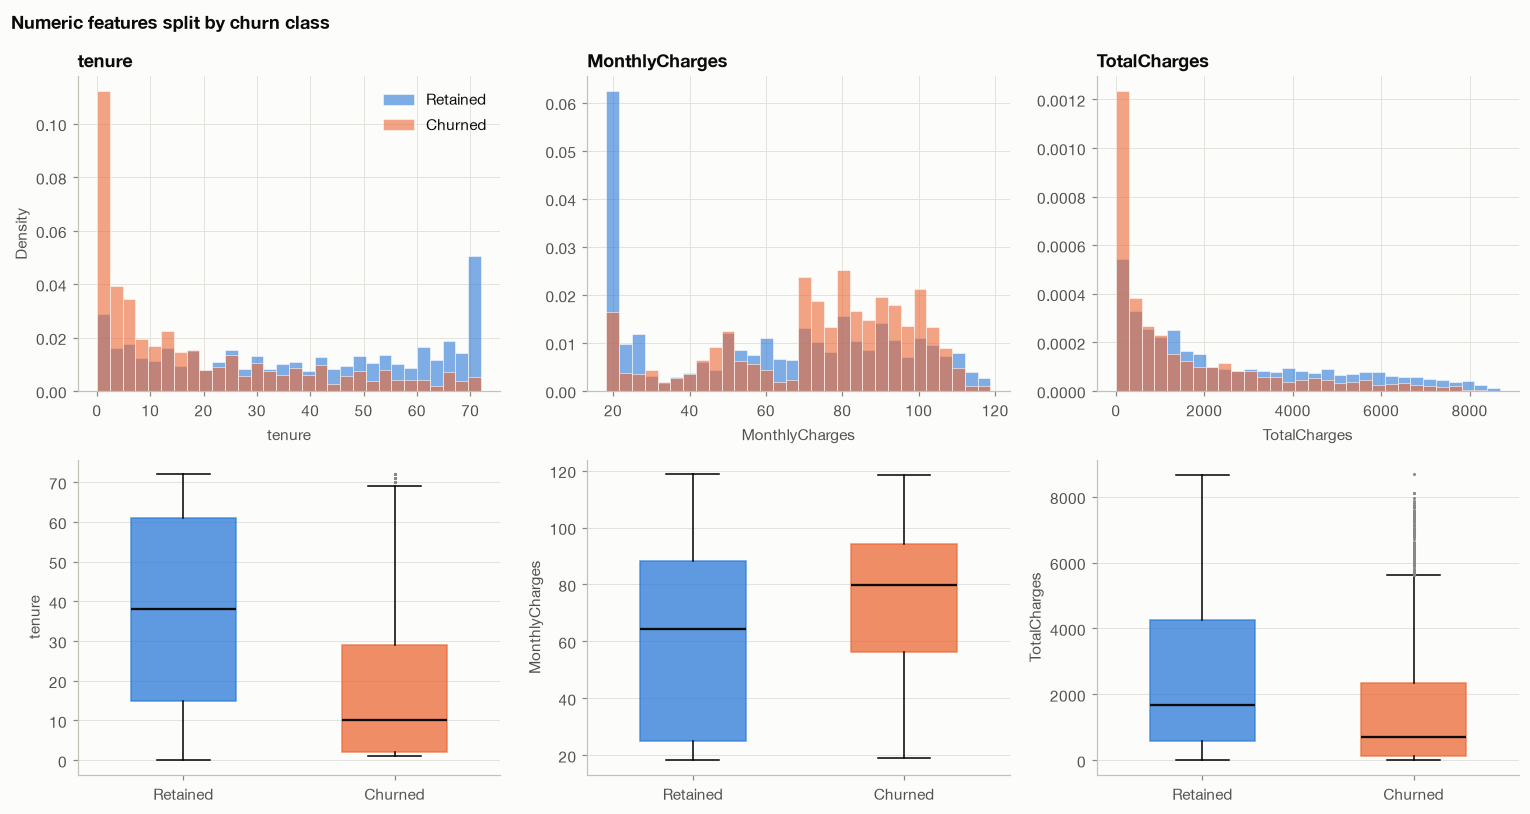

,tenure,MonthlyCharges,TotalCharges
median by class,,,
Churned,10.0,79.65,703.55
Retained,38.0,64.43,1679.52


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for j, col in enumerate(NUMERIC_COLS):
    ax = axes[0, j]
    bins = np.histogram_bin_edges(df[col], bins=30)
    for label, color in [('Retained', P.RETAINED_COLOR), ('Churned', P.CHURN_COLOR)]:
        ax.hist(df.loc[df['ChurnLabel'] == label, col], bins=bins, density=True, alpha=0.6,
                color=color, label=label, edgecolor=P.SURFACE, linewidth=0.6)
    ax.set(title=col, xlabel=col, ylabel='Density' if j == 0 else '')
    if j == 0:
        ax.legend()

    ax = axes[1, j]
    groups = [df.loc[df['ChurnLabel'] == lbl, col] for lbl in ('Retained', 'Churned')]
    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops={'color': P.INK, 'linewidth': 1.5},
                    flierprops={'marker': 'o', 'markersize': 2, 'markerfacecolor': P.MUTED,
                                'markeredgecolor': 'none'})
    for patch, color in zip(bp['boxes'], (P.RETAINED_COLOR, P.CHURN_COLOR)):
        patch.set_facecolor(color); patch.set_alpha(0.75); patch.set_edgecolor(color)
    ax.set_xticks([1, 2], ['Retained', 'Churned'])
    ax.set_ylabel(col)
    ax.grid(axis='x', visible=False)

fig.suptitle('Numeric features split by churn class', x=0.01, ha='left', fontweight='bold')
fig.tight_layout()
P.save_figure(fig, PLOTS / 'feature_distributions_by_churn.png')
plt.show()

df.groupby('ChurnLabel')[NUMERIC_COLS].median().round(2).rename_axis('median by class')

In [9]:
first_year = df.loc[df['tenure'] <= 12, TARGET_COL].mean()
loyal = df.loc[df['tenure'] > 48, TARGET_COL].mean()
print(f'Churn rate, tenure <= 12 months : {first_year:.1%}')
print(f'Churn rate, tenure  > 48 months : {loyal:.1%}')

Churn rate, tenure <= 12 months : 47.4%
Churn rate, tenure  > 48 months : 9.5%


## 5 · Churn rate per category
Each bar is stacked to 100 %; the number on the right is that category's churn rate.

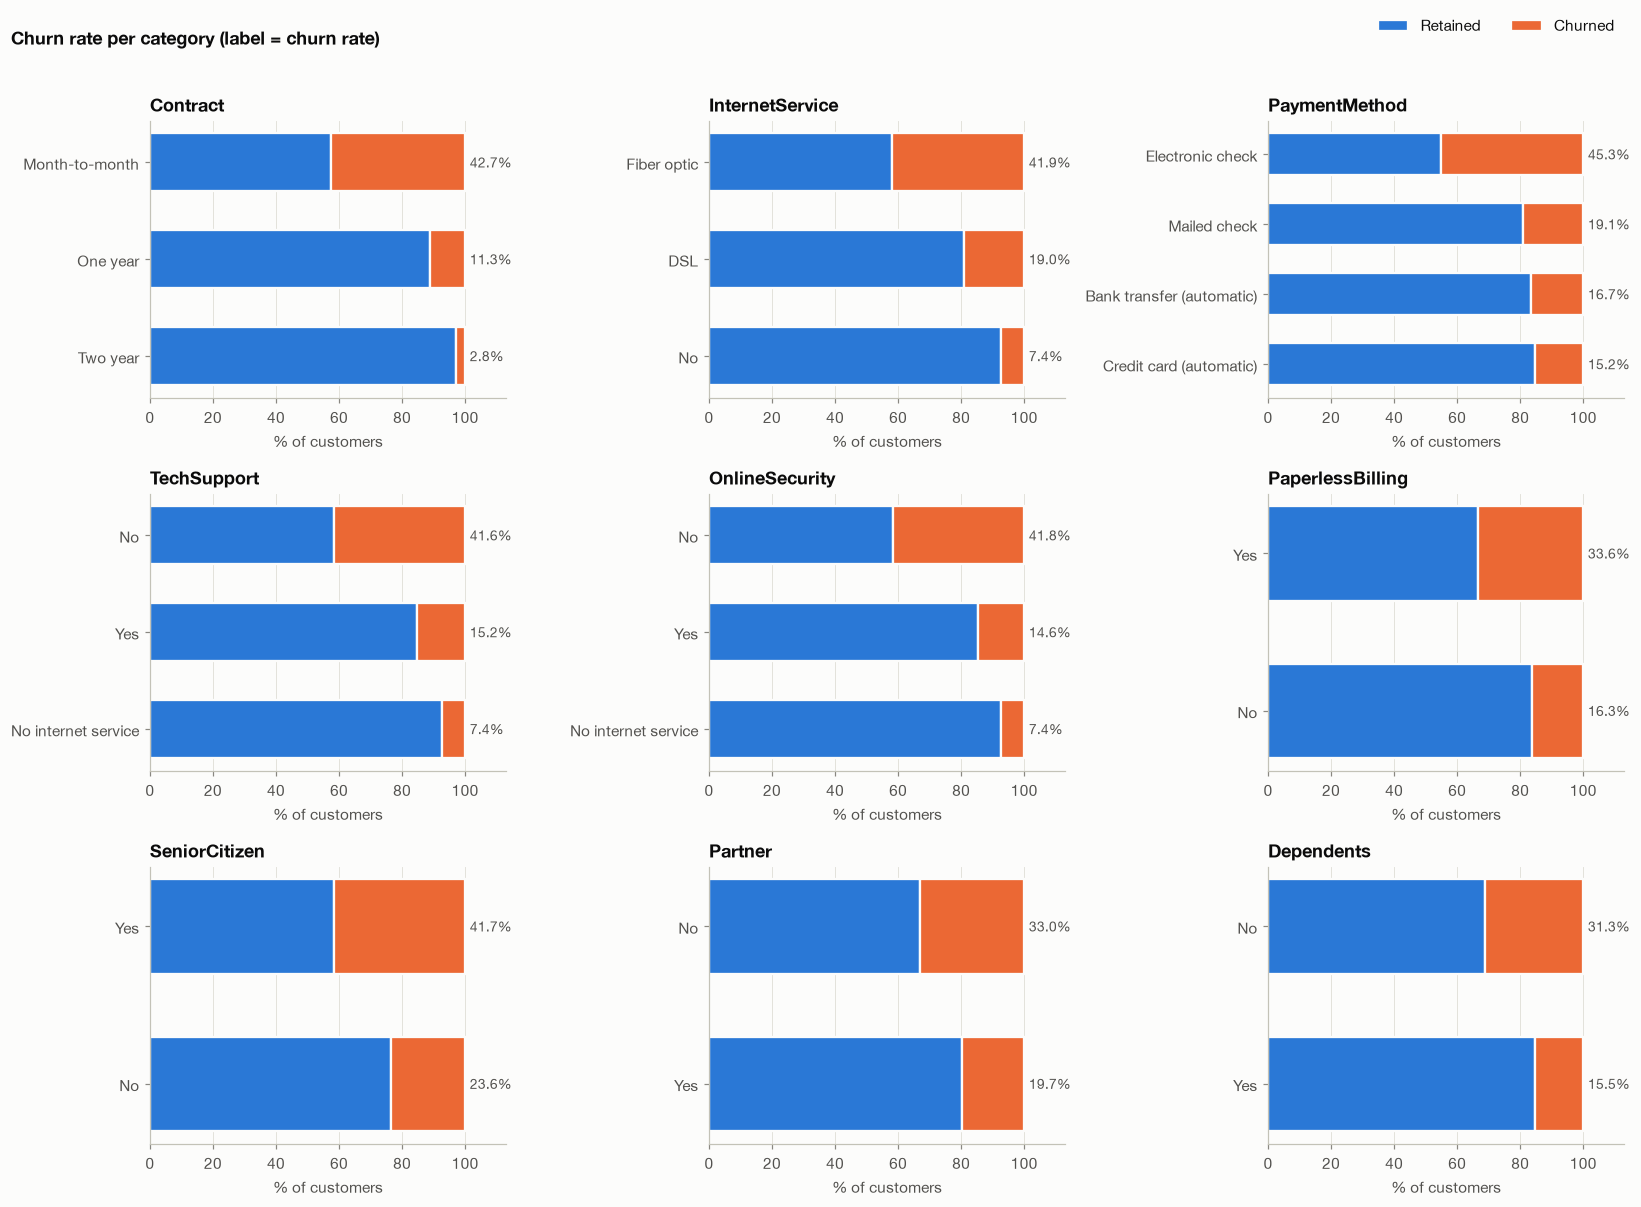

In [10]:
cats = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity',
        'PaperlessBilling', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.ravel(), cats):
    rate = pd.crosstab(df[col], df['ChurnLabel'], normalize='index')[['Retained', 'Churned']] * 100
    rate = rate.sort_values('Churned')
    ax.barh(rate.index, rate['Retained'], color=P.RETAINED_COLOR, edgecolor=P.SURFACE,
            linewidth=1.5, label='Retained', height=0.6)
    ax.barh(rate.index, rate['Churned'], left=rate['Retained'], color=P.CHURN_COLOR,
            edgecolor=P.SURFACE, linewidth=1.5, label='Churned', height=0.6)
    for i, churn_pct in enumerate(rate['Churned']):
        ax.text(101.5, i, f'{churn_pct:.1f}%', va='center', fontsize=9, color=P.INK_SECONDARY)
    ax.set_xlim(0, 113)
    ax.set_title(col)
    ax.set_xlabel('% of customers')
    ax.grid(axis='y', visible=False)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=2, bbox_to_anchor=(0.99, 1.0))
fig.suptitle('Churn rate per category (label = churn rate)', x=0.01, ha='left', fontweight='bold')
fig.tight_layout(rect=(0, 0, 1, 0.97))
P.save_figure(fig, PLOTS / 'categorical_churn_rates.png')
plt.show()

In [11]:
rows = []
for col in cats:
    g = df.groupby(col)[TARGET_COL].agg(churn_rate='mean', customers='size')
    for level, r in g.iterrows():
        rows.append({'feature': col, 'level': level, 'customers': int(r.customers),
                     'churn_rate_%': round(100 * r.churn_rate, 1)})
rates = pd.DataFrame(rows).sort_values('churn_rate_%', ascending=False)
seg = df[(df['InternetService'] == 'Fiber optic') & (df['Contract'] == 'Month-to-month')]
print(f'Fibre optic AND month-to-month: {len(seg):,} customers, churn rate {seg[TARGET_COL].mean():.1%}')
rates.head(10)

Fibre optic AND month-to-month: 2,128 customers, churn rate 54.6%


,feature,level,customers,churn_rate_%
8,PaymentMethod,Electronic check,2365,45.3
0,Contract,Month-to-month,3875,42.7
4,InternetService,Fiber optic,3096,41.9
13,OnlineSecurity,No,3498,41.8
19,SeniorCitizen,Yes,1142,41.7
10,TechSupport,No,3473,41.6
17,PaperlessBilling,Yes,4171,33.6
20,Partner,No,3641,33.0
22,Dependents,No,4933,31.3
18,SeniorCitizen,No,5901,23.6


## 6 · Correlation heatmap (numeric features + encoded target)

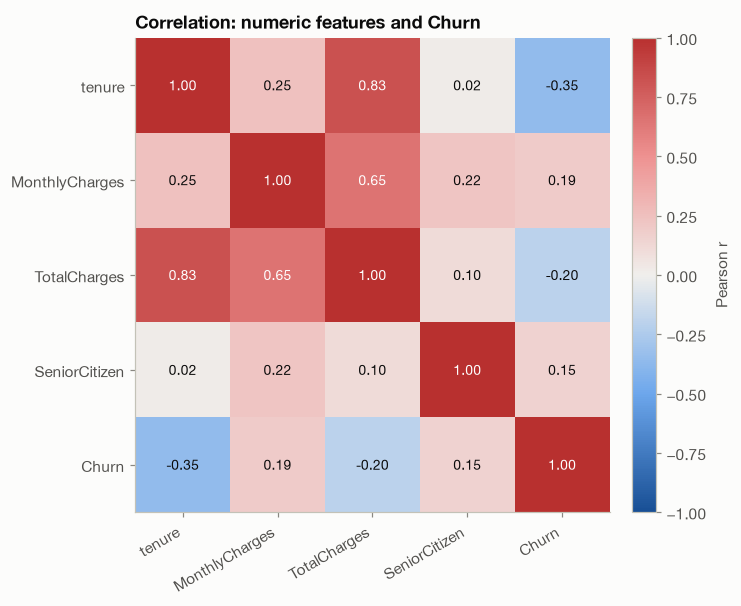

tenure           -0.352229
TotalCharges     -0.198324
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Name: Churn, dtype: float64

In [12]:
corr_df = df[NUMERIC_COLS].copy()
corr_df['SeniorCitizen'] = (df['SeniorCitizen'] == 'Yes').astype(int)
corr_df['Churn'] = df[TARGET_COL]
corr = corr_df.corr()

fig, ax = plt.subplots(figsize=(6.6, 5.6))
im = ax.imshow(corr, cmap=P.DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=30, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(v) > 0.6 else P.INK)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title('Correlation: numeric features and Churn')
P.save_figure(fig, PLOTS / 'correlation_heatmap.png')
plt.show()
corr['Churn'].drop('Churn').sort_values()

The heatmap only covers numeric columns. To see every service/contract level on the same scale, we one-hot encode the full table **for EDA only** (`pd.get_dummies`; nothing here is reused by the model) and rank each dummy's correlation with churn.

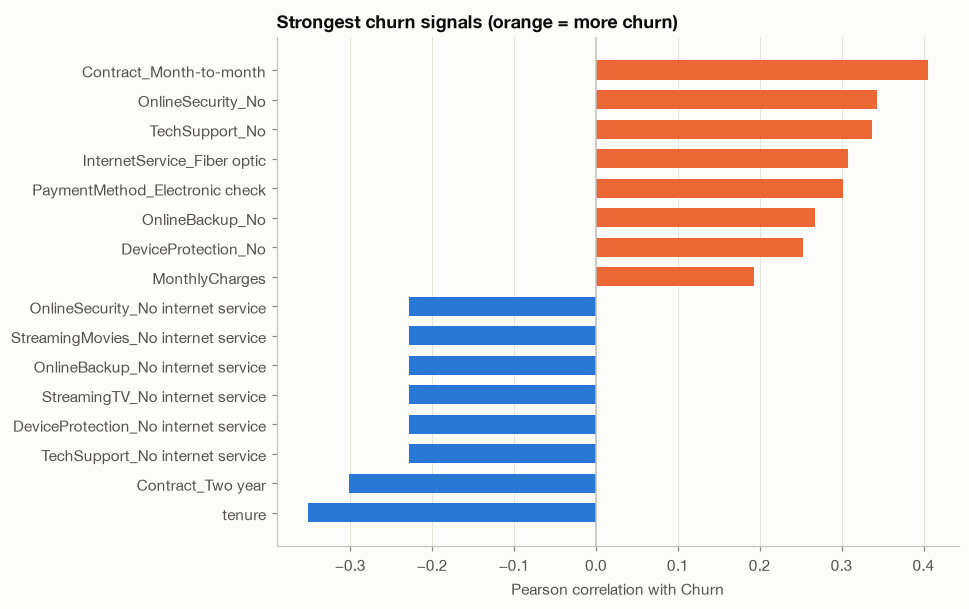

In [13]:
dummies = pd.get_dummies(df[CATEGORICAL_COLS], dtype=float)
ranking = pd.concat([dummies, df[NUMERIC_COLS]], axis=1).corrwith(df[TARGET_COL]).sort_values()
top = pd.concat([ranking.head(8), ranking.tail(8)])

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top.index, top.values, color=[P.CHURN_COLOR if v > 0 else P.RETAINED_COLOR for v in top.values],
        height=0.65)
ax.axvline(0, color=P.AXIS, linewidth=1)
ax.grid(axis='y', visible=False)
ax.set(xlabel='Pearson correlation with Churn', title='Strongest churn signals (orange = more churn)')
P.save_figure(fig, PLOTS / 'churn_correlation_ranking.png')
plt.show()

## 7 · Key observations

1. **Imbalance.** 1,869 of 7,043 customers (**26.5 %**) churned — a 2.77 : 1 ratio. A "nobody churns" model is 73.5 % accurate and worthless, so we judge models on churn-class F1 and PR-AUC and test class weights / oversampling / focal loss.
2. **Contract is the single strongest driver.** Month-to-month customers churn at **42.7 %**, versus **11.3 %** on one-year and **2.8 %** on two-year contracts — a 15× gap.
3. **New customers leave.** Median tenure is **10 months** for churners vs **38** for retained customers; first-year customers churn at **47.4 %** versus **9.5 %** after four years (r = −0.35 with churn).
4. **Price and product.** Fibre-optic customers churn at **41.9 %** (DSL 19.0 %) and churners pay more per month (median 79.65 vs 64.43). The **fibre + month-to-month** segment (2,128 customers) churns at **54.6 %**.
5. **Payment & support.** Electronic-check payers churn at **45.3 %** (other methods 15–19 %). Customers *without* TechSupport or OnlineSecurity churn at ~**42 %**, versus ~**15 %** with them — natural retention levers.

**Implications for modelling:** (i) use imbalance-aware metrics and losses; (ii) `TotalCharges` ≈ tenure × MonthlyCharges (r = 0.83 with tenure) is partly redundant — L2 weight decay and dropout keep the network from over-relying on correlated inputs; (iii) the strong interactions (fibre × month-to-month) motivate a non-linear MLP on top of the linear baselines.